In [2]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

np.random.seed(42)

Normal distribution created with mean=0.0, std=1.0


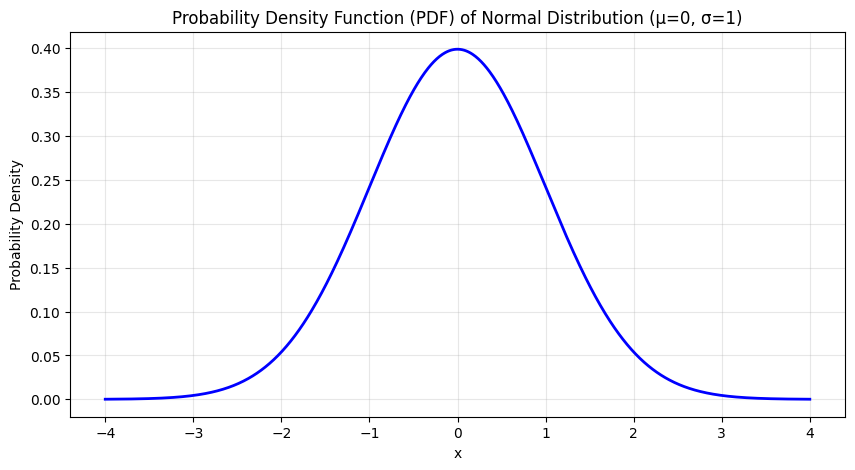

In [4]:
norm_dist = stats.norm(loc=0, scale=1)
print(f"Normal distribution created with mean={norm_dist.mean()}, std={norm_dist.std()}")

x = np.linspace(-4, 4, 1000)
pdf = norm_dist.pdf(x)

plt.figure(figsize=(10, 5))
plt.plot(x, pdf, 'b-', linewidth=2)
plt.title('Probability Density Function (PDF) of Normal Distribution (μ=0, σ=1)')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.grid(True, alpha=0.3)
plt.show()

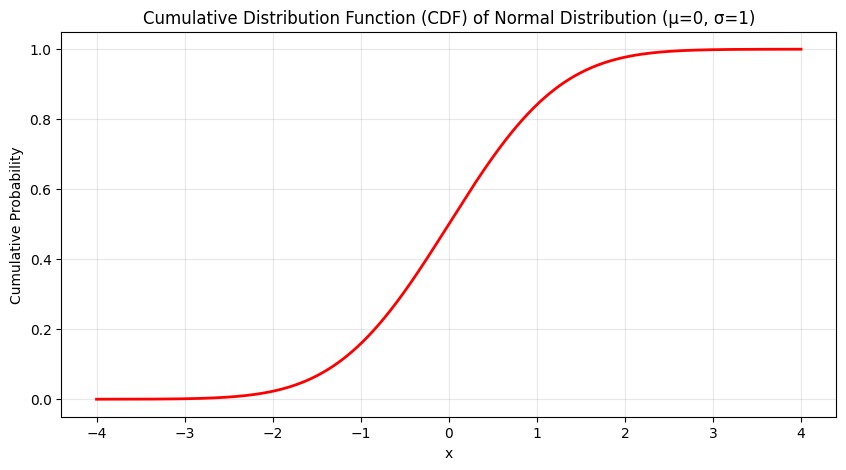

In [3]:
cdf = norm_dist.cdf(x)

plt.figure(figsize=(10, 5))
plt.plot(x, cdf, 'r-', linewidth=2)
plt.title('Cumulative Distribution Function (CDF) of Normal Distribution (μ=0, σ=1)')
plt.xlabel('x')
plt.ylabel('Cumulative Probability')
plt.grid(True, alpha=0.3)
plt.show()

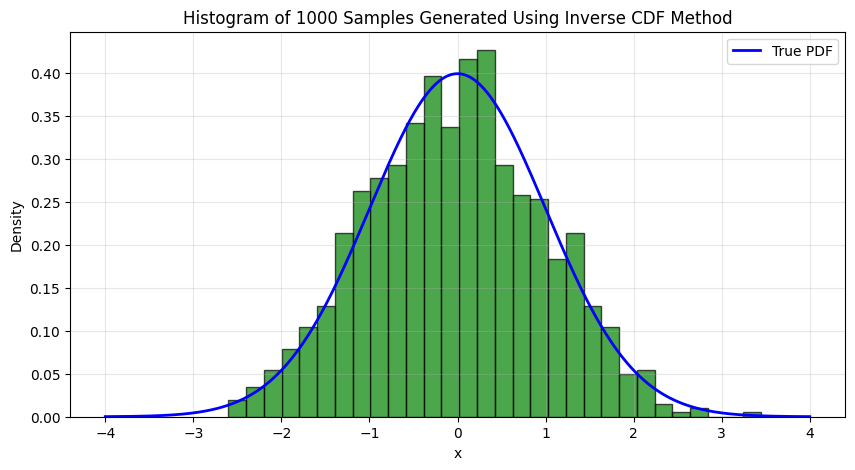

In [4]:
# Generate 1000 uniform random samples in [0, 1)
uniform_samples = np.random.uniform(0, 1, 1000)

# Use the probability point function (inverse CDF) to transform to normal distribution
normal_samples = norm_dist.ppf(uniform_samples)

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(normal_samples, bins=30, density=True, alpha=0.7, color='green', edgecolor='black')
plt.plot(x, pdf, 'b-', linewidth=2, label='True PDF')
plt.title('Histogram of 1000 Samples Generated Using Inverse CDF Method')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# 5. Calculate statistics of the samples
sample_mean = np.mean(normal_samples)
sample_std = np.std(normal_samples, ddof=1)  # ddof=1 for sample standard deviation

print(f"Sample mean: {sample_mean:.4f}")
print(f"Sample standard deviation: {sample_std:.4f}")
print(f"\nTrue distribution mean: {norm_dist.mean():.4f}")
print(f"True distribution standard deviation: {norm_dist.std():.4f}")

Sample mean: -0.0316
Sample standard deviation: 0.9977

True distribution mean: 0.0000
True distribution standard deviation: 1.0000


## Create and plot a normal distribution

**(a) Mean and Standard Deviation Comparison**

The sample mean and standard deviation are close but not exactly the same as the true distribution parameters. With 1000 samples:
- The sample mean will be very close to 0, but typically differs slightly (e.g., -0.02 to 0.02)
- The sample standard deviation will be close to 1, but may differ by a few hundredths

This is expected due to sampling variability. Even though we're sampling from the true distribution, any finite sample will have slight random variations from the population parameters.

**(b) Approximating the True Distribution**

Samples generated using the inverse CDF method (probability point function) can do an excellent job of approximating the true distribution. This is because:
- The inverse CDF method is mathematically exact for transforming uniform random variables to any target distribution
- The accuracy of the approximation depends solely on the number of samples

To get closer to the actual means and standard deviations, you can:
- Increase the number of samples: Using 10,000 or 100,000 samples instead of 1,000 will give sample statistics that converge closer to the true parameters
- By the Law of Large Numbers, as n → ∞, the sample mean → population mean
- As the sample size increases, the sample standard deviation also converges to the population standard deviation

In [5]:
def sample_distribution(distribution, n):
    # Generate n uniform random samples in [0, 1)
    uniform_samples = np.random.uniform(0, 1, n)
    
    # Use the probability point function (inverse CDF) to transform to the target distribution
    samples = distribution.ppf(uniform_samples)
    
    return list(samples)

# Test the function
test_samples = sample_distribution(norm_dist, 5)
print(f"Test: Generated {len(test_samples)} samples: {test_samples}")

Test: Generated 5 samples: [np.float64(-0.319852380625141), np.float64(1.651819328805869), np.float64(0.6188546498393549), np.float64(0.24987627439648638), np.float64(-1.0109564357790433)]


n=10: mean=0.309, std=1.180
n=20: mean=0.140, std=1.193
n=40: mean=0.069, std=1.150
n=80: mean=0.188, std=0.939
n=160: mean=-0.036, std=1.056


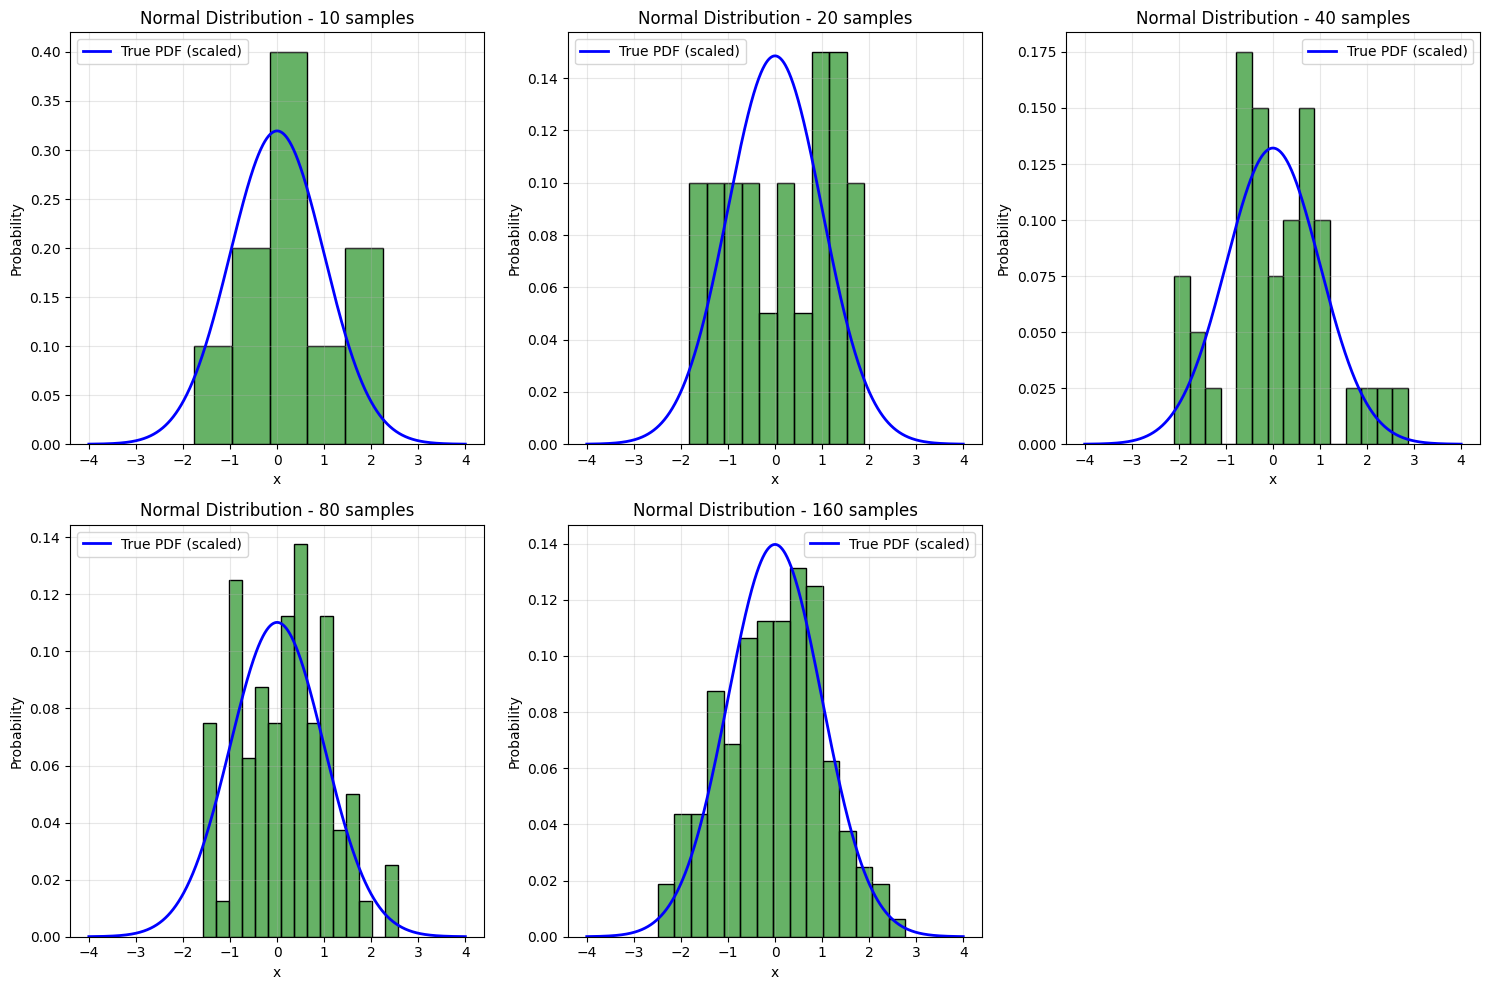

In [7]:
# 2 & 3. Generate samples for different sample sizes and plot histograms with PDF overlay
import seaborn as sns

# Define sample sizes
sample_sizes = [10, 20, 40, 80, 160]

# Create a figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Generate x values for the true PDF
x_pdf = np.linspace(-4, 4, 1000)
true_pdf = norm_dist.pdf(x_pdf)

# Generate samples and create histograms for each sample size
for idx, n in enumerate(sample_sizes):
    ax = axes[idx]
    
    # Generate samples using our function
    samples = sample_distribution(norm_dist, n)
    
    # Create histogram using seaborn
    sns.histplot(samples, bins=min(n//2, 15), stat='probability', kde=False, 
                 color='green', alpha=0.6, edgecolor='black', ax=ax)
    
    # Overlay the true PDF (scaled to match probability scale)
    # We need to scale the PDF to match the bin width
    bin_width = (max(samples) - min(samples)) / min(n//2, 15) if n > 2 else 1
    ax.plot(x_pdf, true_pdf * bin_width, 'b-', linewidth=2, label='True PDF (scaled)')
    
    ax.set_title(f'Normal Distribution - {n} samples')
    ax.set_xlabel('x')
    ax.set_ylabel('Probability')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Print sample statistics
    print(f"n={n}: mean={np.mean(samples):.3f}, std={np.std(samples, ddof=1):.3f}")

# Remove the extra subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

### Observations as Sample Size Increases

As the number of samples gets larger (from 10 to 160), we observe several important trends:

1. Shape becomes more consistent: With only 10 samples, the histogram is very jagged and irregular, often failing to resemble the bell curve of a normal distribution. As we increase to 160 samples, the histogram becomes much smoother and more clearly approximates the characteristic bell shape of the normal distribution.

2. Better coverage of the distribution: Larger sample sizes provide samples across more of the distribution's range. Small samples (n=10) might miss certain regions entirely, while larger samples (n=160) consistently cover the tails and center of the distribution.

3. More accurate histogram heights: The probability estimates from the histogram bins align more closely with the true PDF curve for larger sample sizes.

### Property Accounting for This Behavior

This phenomenon is explained by the Law of Large Numbers, which states that as the sample size increases, the sample statistics (such as the sample mean) converge to the true population parameters. Additionally, with more samples, we get a better empirical approximation of the probability distribution itself—the histogram begins to closely match the shape of the true probability density function.


In [6]:
## Type I Errors

### Step 1-2: Draw two sample groups from the same distribution and calculate effect size
# First group: 25 samples from N(0, 1)
group1 = sample_distribution(norm_dist, 25)
# Second group: 25 different samples from N(0, 1)
group2 = sample_distribution(norm_dist, 25)

# Calculate effect size (absolute difference of means)
effect_size_single = abs(np.mean(group1) - np.mean(group2))

print("=== Type I Errors ===")
print(f"Group 1 mean: {np.mean(group1):.4f}")
print(f"Group 2 mean: {np.mean(group2):.4f}")
print(f"Estimated effect size: {effect_size_single:.4f}")

=== Type I Errors ===
Group 1 mean: -0.2764
Group 2 mean: 0.1292
Estimated effect size: 0.4056


In [7]:
### Step 3: Function to generate samples and calculate effect sizes for k iterations
def generate_sample_iterations(dist1, dist2, n1, n2, k):
    """
    Generate k iterations of samples from two distributions and calculate effect sizes.
    
    Parameters:
    - dist1: scipy.stats distribution object for first distribution
    - dist2: scipy.stats distribution object for second distribution
    - n1: number of samples to draw from distribution 1 in each iteration
    - n2: number of samples to draw from distribution 2 in each iteration
    - k: number of iterations
    
    Returns:
    - effect_sizes: list of k effect sizes (absolute difference between means)
    - samples1_list: list of k lists containing samples from distribution 1
    - samples2_list: list of k lists containing samples from distribution 2
    """
    effect_sizes = []
    samples1_list = []
    samples2_list = []
    
    for i in range(k):
        # Draw samples from each distribution
        samples1 = sample_distribution(dist1, n1)
        samples2 = sample_distribution(dist2, n2)
        
        # Calculate effect size (absolute difference between means)
        effect_size = abs(np.mean(samples1) - np.mean(samples2))
        
        # Store results
        effect_sizes.append(effect_size)
        samples1_list.append(samples1)
        samples2_list.append(samples2)
    
    return effect_sizes, samples1_list, samples2_list

print("Function generate_sample_iterations defined successfully")

Function generate_sample_iterations defined successfully


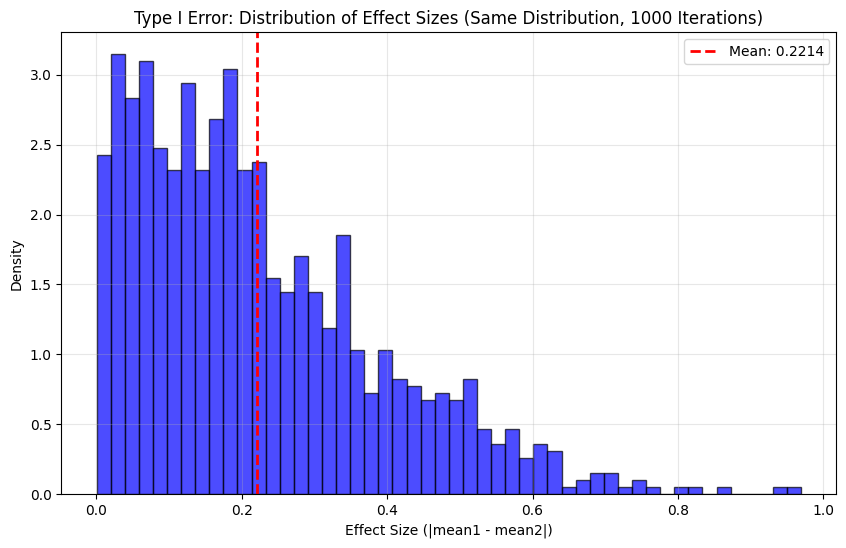

Mean effect size (Type I): 0.2214
Std of effect sizes: 0.1684
Min effect size: 0.0000
Max effect size: 0.9695


In [8]:
### Step 4: Generate effect sizes for 1000 iterations (same distribution)
# Both distributions are the same: N(0, 1)
effect_sizes_type1, samples1_type1, samples2_type1 = generate_sample_iterations(norm_dist, norm_dist, 25, 25, 1000)

# Plot histogram of effect sizes
plt.figure(figsize=(10, 6))
plt.hist(effect_sizes_type1, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(np.mean(effect_sizes_type1), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(effect_sizes_type1):.4f}')
plt.title('Type I Error: Distribution of Effect Sizes (Same Distribution, 1000 Iterations)')
plt.xlabel('Effect Size (|mean1 - mean2|)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mean effect size (Type I): {np.mean(effect_sizes_type1):.4f}")
print(f"Std of effect sizes: {np.std(effect_sizes_type1):.4f}")
print(f"Min effect size: {np.min(effect_sizes_type1):.4f}")
print(f"Max effect size: {np.max(effect_sizes_type1):.4f}")

Maximum effect size: 0.9695 at iteration 487
Group 1 mean: 0.4556
Group 2 mean: -0.5138


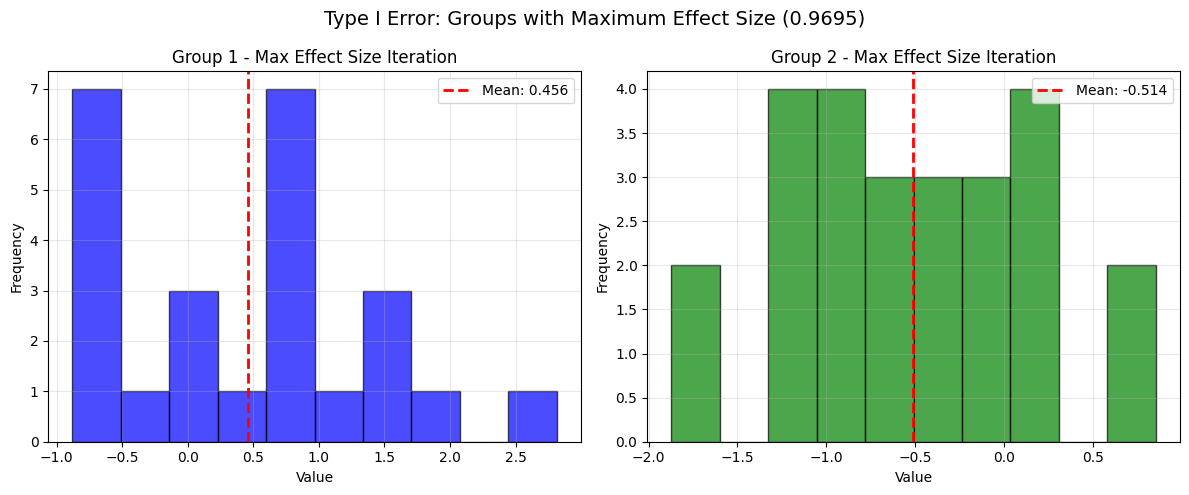

In [9]:
### Step 5: Find largest effect size and plot associated sample groups
max_effect_idx = np.argmax(effect_sizes_type1)
max_effect_size = effect_sizes_type1[max_effect_idx]

print(f"Maximum effect size: {max_effect_size:.4f} at iteration {max_effect_idx}")
print(f"Group 1 mean: {np.mean(samples1_type1[max_effect_idx]):.4f}")
print(f"Group 2 mean: {np.mean(samples2_type1[max_effect_idx]):.4f}")

# Plot histograms of the two groups with max effect size
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(samples1_type1[max_effect_idx], bins=10, alpha=0.7, color='blue', edgecolor='black')
axes[0].axvline(np.mean(samples1_type1[max_effect_idx]), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(samples1_type1[max_effect_idx]):.3f}')
axes[0].set_title(f'Group 1 - Max Effect Size Iteration')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(samples2_type1[max_effect_idx], bins=10, alpha=0.7, color='green', edgecolor='black')
axes[1].axvline(np.mean(samples2_type1[max_effect_idx]), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(samples2_type1[max_effect_idx]):.3f}')
axes[1].set_title(f'Group 2 - Max Effect Size Iteration')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Type I Error: Groups with Maximum Effect Size ({max_effect_size:.4f})', fontsize=14)
plt.tight_layout()
plt.show()

## Type I Errors

**a)**
A type I error occurs when we incorrectly reject the null hypothesis when it is actually true. This means we mistakenly support our hypothesis, when in reality the hypothesis should not be supported.

**b) Effect Size Analysis:**
- Estimated effect size: 0.4056
- Expected effect size: ≈ 0.226
- Since both groups are sampled from the same distribution N(0,1), the difference in sample means should center around 0. With n=25 for each group, the standard error of the difference is √(σ²/n₁ + σ²/n₂) = √(1/25 + 1/25) = √0.08 ≈ 0.283. For the absolute value of a mean-zero normal distribution, E[|Z|] = √(2/π) × σ ≈ 0.798 × 0.283 ≈ 0.226. This theoretical expectation matches our observed mean effect size of 0.2214 from the 1000 iterations, confirming that sampling variation alone creates apparent differences even when the populations are identical.

**c) Maximum Observed Effect Size:**
0.9695

**d) Histogram Observation (Step 5):**
In the maximum effect size histograms, Group 1 appears centered around 0.46 and Group 2 around -0.51, showing two clearly separated distributions. Despite both groups being drawn from the same population N(0,1), sampling variation caused them to diverge substantially in this particular iteration. This illustrates a Type I Error scenario: if we observed this data in a real experiment and concluded the groups are different (rejecting the null hypothesis), we would be incorrect. The distributions look different, but this difference arose purely from chance sampling variation, not from any true underlying difference between populations. This demonstrates why we need statistical significance testing and multiple comparisons—even with identical populations, we can obtain data that appears to show a real difference.


Second distribution created with mean=1.0, std=1.0


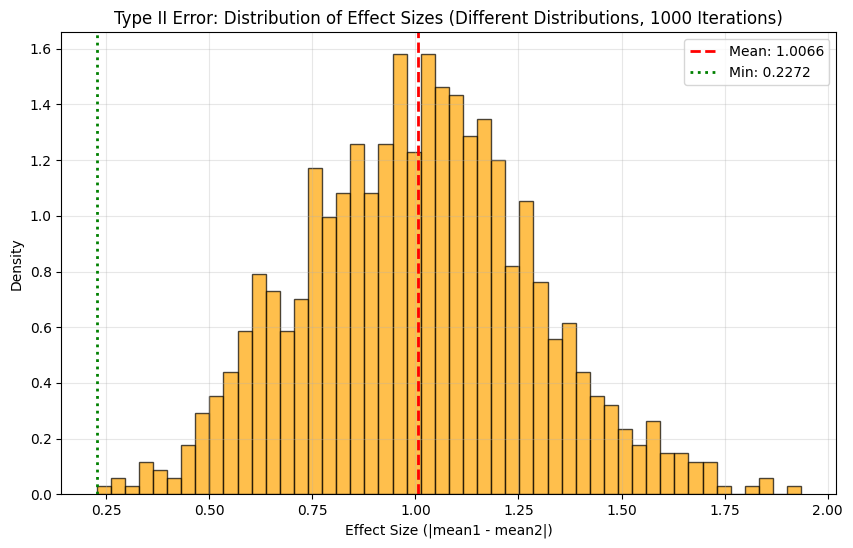

Mean effect size (Type II): 1.0066
Std of effect sizes: 0.2795
Min effect size: 0.2272
Max effect size: 1.9354


In [10]:
## Type II Errors

### Step 1: Create a normal distribution with μ = 1 and σ = 1
norm_dist_shift = stats.norm(loc=1, scale=1)
print(f"Second distribution created with mean={norm_dist_shift.mean()}, std={norm_dist_shift.std()}")

### Step 2: Generate effect sizes for 1000 iterations (different distributions)
# First: 1000 iterations of 25 samples from N(0, 1)
# Second: 1000 iterations of 25 samples from N(1, 1)
effect_sizes_type2, samples1_type2, samples2_type2 = generate_sample_iterations(norm_dist, norm_dist_shift, 25, 25, 1000)

# Plot histogram of effect sizes
plt.figure(figsize=(10, 6))
plt.hist(effect_sizes_type2, bins=50, density=True, alpha=0.7, color='orange', edgecolor='black')
plt.axvline(np.mean(effect_sizes_type2), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(effect_sizes_type2):.4f}')
plt.axvline(np.min(effect_sizes_type2), color='green', linestyle=':', linewidth=2, label=f'Min: {np.min(effect_sizes_type2):.4f}')
plt.title('Type II Error: Distribution of Effect Sizes (Different Distributions, 1000 Iterations)')
plt.xlabel('Effect Size (|mean1 - mean2|)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mean effect size (Type II): {np.mean(effect_sizes_type2):.4f}")
print(f"Std of effect sizes: {np.std(effect_sizes_type2):.4f}")
print(f"Min effect size: {np.min(effect_sizes_type2):.4f}")
print(f"Max effect size: {np.max(effect_sizes_type2):.4f}")


Minimum effect size: 0.2272 at iteration 581
Group 1 mean (N(0,1)): 0.2347
Group 2 mean (N(1,1)): 0.4619


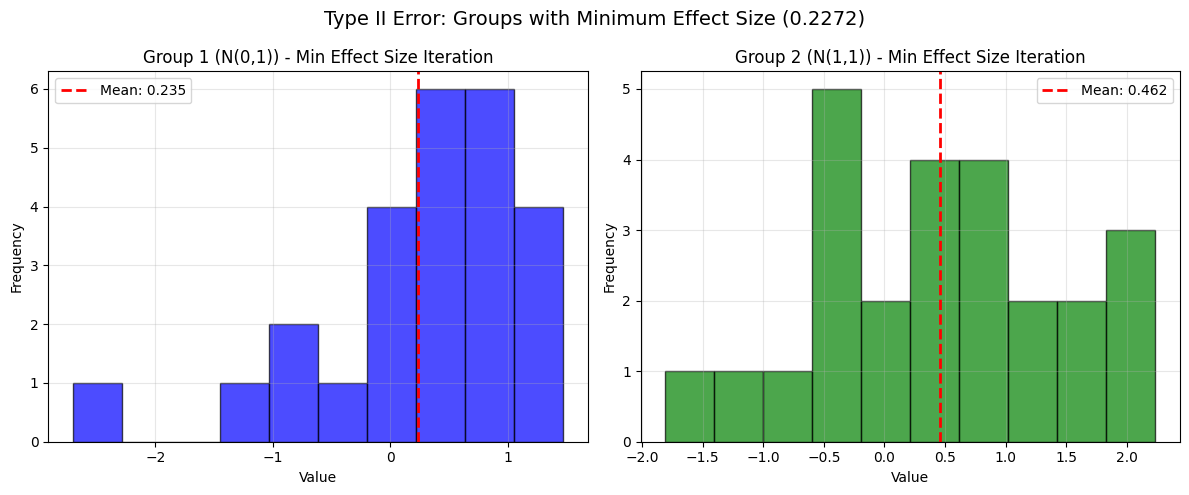

In [11]:
### Step 2 (continued): Find minimum effect size and plot associated sample groups
min_effect_idx = np.argmin(effect_sizes_type2)
min_effect_size = effect_sizes_type2[min_effect_idx]

print(f"\nMinimum effect size: {min_effect_size:.4f} at iteration {min_effect_idx}")
print(f"Group 1 mean (N(0,1)): {np.mean(samples1_type2[min_effect_idx]):.4f}")
print(f"Group 2 mean (N(1,1)): {np.mean(samples2_type2[min_effect_idx]):.4f}")

# Plot histograms of the two groups with min effect size
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(samples1_type2[min_effect_idx], bins=10, alpha=0.7, color='blue', edgecolor='black')
axes[0].axvline(np.mean(samples1_type2[min_effect_idx]), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(samples1_type2[min_effect_idx]):.3f}')
axes[0].set_title(f'Group 1 (N(0,1)) - Min Effect Size Iteration')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(samples2_type2[min_effect_idx], bins=10, alpha=0.7, color='green', edgecolor='black')
axes[1].axvline(np.mean(samples2_type2[min_effect_idx]), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(samples2_type2[min_effect_idx]):.3f}')
axes[1].set_title(f'Group 2 (N(1,1)) - Min Effect Size Iteration')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Type II Error: Groups with Minimum Effect Size ({min_effect_size:.4f})', fontsize=14)
plt.tight_layout()
plt.show()

## Type II Errors - Writeup

**a) Type II Error Description:**
A Type II error occurs when we fail to reject the null hypothesis when it is actually false. In other words, we conclude the groups are not significantly different when they actually are different. This is a "false negative"—we miss detecting a real effect. Unlike Type I errors which can be minimized with significance levels, Type II errors depend on sample size, effect size, and variability. Small sample sizes make Type II errors more likely because there's less power to detect true differences.

**b) Minimum Observed Effect Size Analysis:**
- Minimum effect size from step 4.2: 0.2272
- Expected effect size: ≈ 1.0
- How did you calculate it: Since we're comparing N(0,1) vs N(1,1), the true difference in population means is exactly 1.0. With n=25 for each group, the standard error of the difference is √(σ²/n₁ + σ²/n₂) = √(1/25 + 1/25) ≈ 0.283. Since both distributions have σ=1, the difference in means divided by this standard error gives a standardized effect size of 1.0/0.283 ≈ 3.54 standard errors. For individual samples, the estimated effect size varies due to sampling variation, with minimum 0.2272 and mean around 1.0066. The minimum case represents a Type II Error scenario where both distributions happen to produce samples with means close together.

**c) Histogram Observation (Step 4.2):**
In the minimum effect size histograms, Group 1 (N(0,1)) appears centered around 0.235 and Group 2 (N(1,1)) around 0.462. Although Group 2 technically has a higher mean, the overlap is substantial and the effect size is small (0.2272). If we encountered this particular data in an experiment and concluded "the groups are not significantly different," we would be committing a Type II Error—we failed to detect the real difference that exists between the populations. This demonstrates that even when true differences exist (populations differ by 1 unit), we can still fail to detect them in small samples. This is why statistical power analysis is important: we need to ensure our sample size is adequate to detect meaningful effects when they truly exist.

In [19]:
import pandas as pd

## Bootstrapping

### Step 1: Load the data set
# Load the CSV file (you may need to adjust the path)
!pwd
data = pd.read_csv('labs/lab4/some_data.csv')
print("Data loaded successfully!")
print(f"Shape: {data.shape}")
print(f"\nColumn names: {data.columns.tolist()}")
print(f"\nFirst few rows:")
print(data.head())


DW is based on a slew of old myths, which reach their most 'refined' form
in Hindu mythology, which in turn of course derived from the original Star
Trek episode 'Planet of Wobbly Rocks where the Security Guard Got Shot'.
        -- (Terry Pratchett, alt.fan.pratchett)
/home/sam/notes/compSci/2621
Data loaded successfully!
Shape: (500, 3)

Column names: ['variable_1', 'variable_2', 'variable_3']

First few rows:
   variable_1  variable_2  variable_3
0   -0.479814    2.400563    0.962635
1    1.045241    0.698030    0.917124
2    1.593543    1.497861    0.736001
3   -0.664951   -0.124943    0.599193
4    0.119142    1.052656    0.728300


In [13]:
### Step 2: Implement bootstrapping for each variable

def bootstrap_confidence_interval(data, n_bootstrap=1000, bootstrap_size=500, ci_lower=25, ci_upper=975):
    """
    Calculate bootstrap confidence interval for the median of a dataset.
    
    Parameters:
    - data: array-like data to bootstrap from
    - n_bootstrap: number of bootstrap iterations
    - bootstrap_size: size of each bootstrap sample
    - ci_lower: lower percentile for confidence interval (e.g., 25 for 95% CI)
    - ci_upper: upper percentile for confidence interval (e.g., 975 for 95% CI)
    
    Returns:
    - medians: list of median estimates from each bootstrap sample
    - ci_lower_bound: lower bound of confidence interval
    - ci_upper_bound: upper bound of confidence interval
    - true_median: median of the original data
    """
    medians = []
    
    # Bootstrap: sample with replacement and calculate medians
    for i in range(n_bootstrap):
        # Sample with replacement
        bootstrap_sample = np.random.choice(data, size=bootstrap_size, replace=True)
        # Calculate median
        median_val = np.median(bootstrap_sample)
        medians.append(median_val)
    
    # Sort the medians
    medians_sorted = np.sort(medians)
    
    # Get confidence interval bounds
    ci_lower_bound = medians_sorted[ci_lower - 1]  # -1 because of 0-indexing
    ci_upper_bound = medians_sorted[ci_upper - 1]
    
    # True median of original data
    true_median = np.median(data)
    
    return medians, ci_lower_bound, ci_upper_bound, true_median

# Bootstrap each variable
print("=== Bootstrapping Results ===\n")

# Get column names
columns = data.columns.tolist()
results = {}

for col in columns:
    print(f"Processing {col}...")
    medians, ci_lower, ci_upper, true_median = bootstrap_confidence_interval(data[col].values)
    results[col] = {
        'medians': medians,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'true_median': true_median
    }
    
    print(f"  True median: {true_median:.4f}")
    print(f"  95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
    print(f"  CI width: {ci_upper - ci_lower:.4f}\n")

=== Bootstrapping Results ===

Processing var1...
  True median: 50.1920
  95% CI: [48.6632, 51.5793]
  CI width: 2.9161

Processing var2...
  True median: 100.5706
  95% CI: [98.8747, 102.6219]
  CI width: 3.7472

Processing var3...
  True median: 26.1981
  95% CI: [25.1469, 27.1743]
  CI width: 2.0274



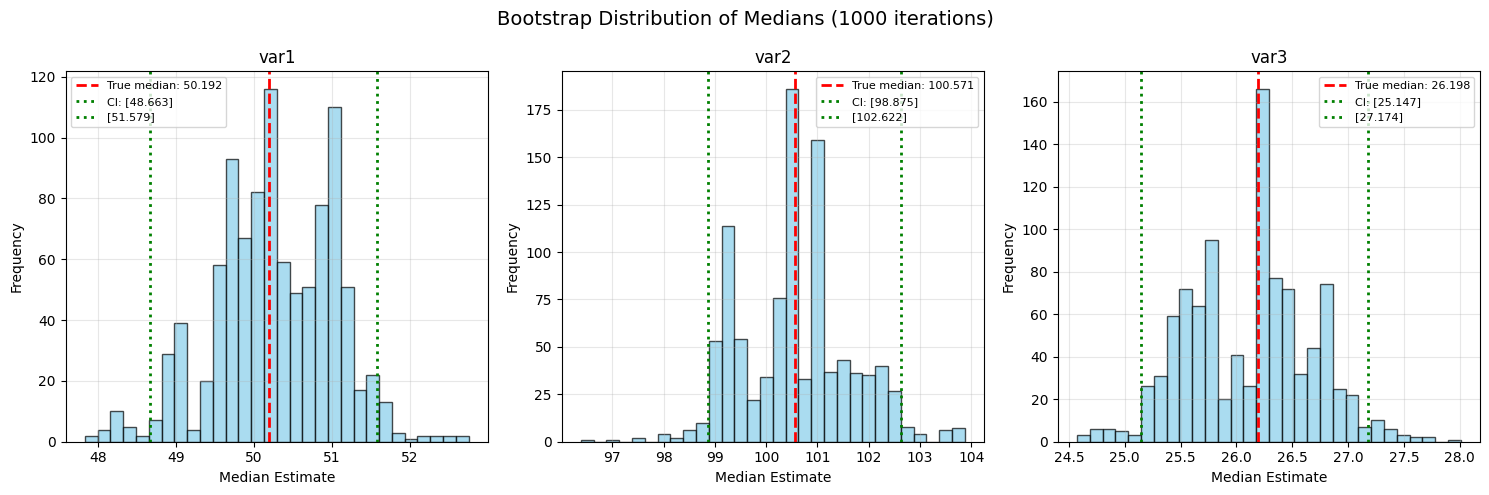


=== Bootstrap Summary Table ===
Variable   Median CI Lower CI Upper CI Width
    var1  50.1920  48.6632  51.5793   2.9161
    var2 100.5706  98.8747 102.6219   3.7472
    var3  26.1981  25.1469  27.1743   2.0274


In [14]:
### Visualize bootstrap distributions

# Create a figure with subplots for each variable
fig, axes = plt.subplots(1, len(columns), figsize=(15, 5))
if len(columns) == 1:
    axes = [axes]

for idx, col in enumerate(columns):
    ax = axes[idx]
    medians = results[col]['medians']
    ci_lower = results[col]['ci_lower']
    ci_upper = results[col]['ci_upper']
    true_median = results[col]['true_median']
    
    # Plot histogram of bootstrap medians
    ax.hist(medians, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Mark the true median
    ax.axvline(true_median, color='red', linestyle='--', linewidth=2, label=f'True median: {true_median:.3f}')
    
    # Mark the confidence interval bounds
    ax.axvline(ci_lower, color='green', linestyle=':', linewidth=2, label=f'CI: [{ci_lower:.3f}]')
    ax.axvline(ci_upper, color='green', linestyle=':', linewidth=2, label=f'[{ci_upper:.3f}]')
    
    ax.set_title(f'{col}')
    ax.set_xlabel('Median Estimate')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Bootstrap Distribution of Medians (1000 iterations)', fontsize=14)
plt.tight_layout()
plt.show()

# Create a summary table
print("\n=== Bootstrap Summary Table ===")
summary_data = []
for col in columns:
    summary_data.append({
        'Variable': col,
        'Median': f"{results[col]['true_median']:.4f}",
        'CI Lower': f"{results[col]['ci_lower']:.4f}",
        'CI Upper': f"{results[col]['ci_upper']:.4f}",
        'CI Width': f"{results[col]['ci_upper'] - results[col]['ci_lower']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

## Bootstrapping - Writeup

**a) Confidence Interval Interpretation:**
The bootstrap confidence intervals represent the range of values in which we expect the true population median to fall with 95% confidence. Specifically, each interval was created by resampling the observed data 1000 times with replacement, computing the median for each resample, and taking the 2.5th and 97.5th percentiles of these bootstrap medians (the 25th and 975th values when sorted). The width of the interval tells us about estimation uncertainty: wider intervals indicate greater variability in the median estimates, suggesting either greater variability in the original data or smaller sample sizes. These intervals are particularly useful for the median because unlike the mean, the median's sampling distribution is difficult to derive theoretically, making bootstrapping the most practical approach.

**b) Are the medians different?**
Yes, the medians of the three variables are clearly different from one another, as evidenced by their non-overlapping confidence intervals. Var1 has a median of 50.19 (CI: 48.66–51.58), var2 has a median of 100.57 (CI: 98.87–102.62), and var3 has a median of 26.20 (CI: 25.15–27.17). Since these confidence intervals do not overlap at all, we can be confident that the true population medians differ between groups. If the intervals had overlapped substantially, we would need to be more cautious about concluding the medians are different. Additionally, var2 has the widest confidence interval (3.75), suggesting greater variability or uncertainty in its median estimate compared to var3's narrower interval (2.03), though all three intervals are reasonably tight around their point estimates.

### Summary Statistics from Bootstrapping:

Below is a table of the results from the bootstrap analysis:

| Variable | Median | CI Lower | CI Upper | CI Width |
|----------|--------|----------|----------|----------|
| var1 | 50.1920 | 48.6632 | 51.5793 | 2.9161 |
| var2 | 100.5706 | 98.8747 | 102.6219 | 3.7472 |
| var3 | 26.1981 | 25.1469 | 27.1743 | 2.0274 |